In [6]:
import meep as mp
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt

resolution = 50 # pixels/unit length

wvl_min = 1.5
wvl_max = 1.6
wvl_cen = 0.5*(wvl_min+wvl_max)
fmin = 1/wvl_max
fmax = 1/wvl_min
fcen = 0.5*(fmin+fmax)
df = fmax-fmin
nfreq = 10

dpml = 1.0 #PML thickness
dsub = 1.5 + wvl_cen #substrate thickness
dpad = dsub #padding between cell and PML

k_point = mp.Vector3(0,0,0) #used for PBC

n_si = 3.45 #silicon refractive index
si = mp.Medium(index=n_si)
n_sio2 = 1.45
sio2 = mp.Medium(index=n_sio2)
n_air = 1.0 #air refractive index
air = mp.Medium(index=n_air)

In [8]:
P = 0.7 #unit cell pitch
h = 0.8 #pillar height

def unitCell_paramsweep(D):
    sim_x_size = dpml + dsub + dpad + dpml
    sim_z_size = P
    sim_y_size = P

    cell_size = mp.Vector3(sim_x_size, sim_y_size, sim_z_size)

    source_position = mp.Vector3(-wvl_cen,0,0) #source position in the middle of the substrate
    source = mp.Source(
        mp.GaussianSource(fcen, fwidth=df),
        component = mp.Ez,
        center = source_position,
        size = mp.Vector3(0, sim_y_size, sim_z_size),
    )

    pml_layers = [mp.PML(dpml,direction=mp.X)]

    monitor_position = mp.Vector3(h + wvl_cen,0,0)
    obs_point = monitor_position
    stop_cond = mp.stop_when_fields_decayed(50, mp.Ez, obs_point, 1e-9)
    #stop_cond_time = 50
    sim = mp.Simulation(
        resolution = resolution,
        cell_size = cell_size,
        boundary_layers = pml_layers,
        k_point = k_point,
        default_material = sio2,
        sources = [source],
    )

    flux_mon = sim.add_flux(
        fcen, 
        df,
        nfreq, 
        mp.FluxRegion(center=monitor_position, size=mp.Vector3(0, sim_y_size, sim_z_size))
    )

    sim.run(until_after_sources=stop_cond)
    input_flux = mp.get_fluxes(flux_mon)

    sim.reset_meep()

    pillar_geo = mp.Cylinder(
        material = si,
        radius = D/2,
        height = h,
        center = mp.Vector3(h/2,0,0),
        axis=mp.Vector3(1,0,0),
    )

    substrate_geo = mp.Block(
        material = sio2,
        size = mp.Vector3(dsub+dpml, mp.inf, mp.inf),
        center = mp.Vector3(-(dsub+dpml)/2,0,0),
    )

    geometries = [substrate_geo, pillar_geo]

    sim = mp.Simulation(
        resolution = resolution,
        cell_size = cell_size,
        boundary_layers = pml_layers,
        geometry = geometries,
        k_point = k_point,
        sources = [source],
    )

    mode_mon = sim.add_flux(
        fcen, df, nfreq, mp.FluxRegion(center=monitor_position, size=mp.Vector3(0, sim_y_size, sim_z_size))
    )#this monitor accumulates fields 

    f, ax = plt.subplots(1,2,dpi=120)
    xy_plane = mp.Volume(center=mp.Vector3(0,0,h/2), size=mp.Vector3(sim_x_size,sim_y_size,0))
    sim.plot2D(ax=ax[1],output_plane=xy_plane,show_sources=True,show_monitors=True,show_epsilon=True)
    ax[1].set_xlim(-sim_x_size/2, sim_x_size/2)
    ax[1].set_ylim(-sim_y_size/2, sim_y_size/2)
    plt.show()

    sim.run(until_after_sources=stop_cond)

    freqs = mp.get_eigenmode_freqs(mode_mon)
    res = sim.get_eigenmode_coefficients(
        mode_mon, [1], eig_parity=mp.ODD_Z + mp.EVEN_Y
    )
    coeffs = res.alpha

    mode_wvl = [1/freqs[nf] for nf in range(nfreq)]
    mode_tran = [abs(coeffs[0,nf,0])**2 / input_flux[nf] for nf in range(nfreq)]
    mode_phase = [np.angle(coeffs[0,nf,0]) for nf in range(nfreq)]

    return mode_wvl, mode_tran, mode_phase

diameters = np.linspace(0.2, 0.6, 4)
mode_tran_arr = np.empty((len(diameters), nfreq))
mode_phase_arr = np.empty((len(diameters), nfreq))

for i, D in enumerate(diameters):
    mode_wvl, mode_tran, mode_phase = unitCell_paramsweep(D)
    mode_tran_arr[i,:] = mode_tran
    mode_phase_arr[i,:] = mode_phase

-----------
Initializing structure...
time for choose_chunkdivision = 6.38962e-05 s
Working in 3D dimensions.
Computational cell is 8.1 x 0.7 x 0.7 with resolution 50
time for set_epsilon = 0.787619 s
-----------
on time step 535 (time=5.35), 0.0074768 s/step
on time step 1171 (time=11.71), 0.00629888 s/step
on time step 1829 (time=18.29), 0.00608258 s/step
on time step 2488 (time=24.88), 0.00607308 s/step
on time step 3145 (time=31.45), 0.00609221 s/step
on time step 3807 (time=38.07), 0.00604308 s/step
on time step 4467 (time=44.67), 0.00606241 s/step
field decay(t = 50.01): 5.426741164771886e-06 / 5.426741164771886e-06 = 1.0
on time step 5127 (time=51.27), 0.00606334 s/step
on time step 5738 (time=57.38), 0.00655712 s/step
on time step 6373 (time=63.73), 0.00630479 s/step
on time step 7031 (time=70.31), 0.0060838 s/step
on time step 7662 (time=76.62), 0.00634715 s/step
on time step 8302 (time=83.02), 0.00625346 s/step
on time step 8959 (time=89.59), 0.00609081 s/step
on time step 96

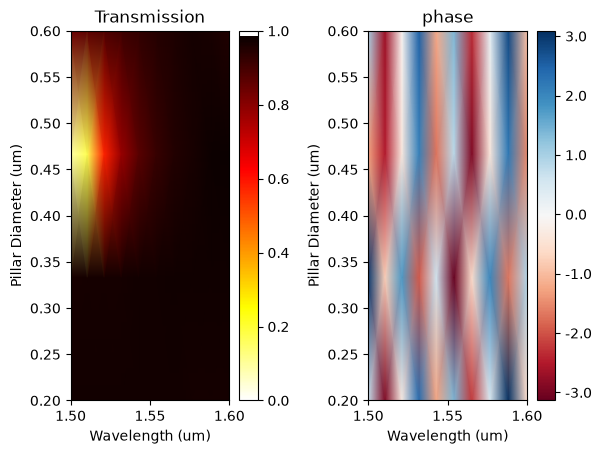

In [14]:
plt.figure()
plt.subplot(1,2,1)
plt.pcolormesh(
    mode_wvl,
    diameters,
    mode_tran_arr,
    cmap='hot_r',
    shading='gouraud',
    vmin=0,
    vmax=mode_tran_arr.max(),
)

plt.axis([wvl_min, wvl_max, diameters[0], diameters[-1]])
plt.xlabel("Wavelength (um)")
plt.xticks([t for t in np.linspace(wvl_min, wvl_max, 3)])
plt.ylabel("Pillar Diameter (um)")
plt.title("Transmission")
cbar=plt.colorbar()
cbar.set_ticks([t for t in np.arange(0, 1.2, 0.2)])
cbar.set_ticklabels(["{:.1f}".format(t) for t in np.linspace(0, 1, 6)])

plt.subplot(1,2,2)
plt.pcolormesh(
    mode_wvl,
    diameters,
    mode_phase_arr,
    cmap='RdBu',
    shading='gouraud',
    vmin=mode_phase_arr.min(),
    vmax=mode_phase_arr.max(),
)

plt.axis([wvl_min, wvl_max, diameters[0], diameters[-1]])
plt.xlabel("Wavelength (um)")
plt.xticks([t for t in np.linspace(wvl_min, wvl_max, 3)])
plt.ylabel("Pillar Diameter (um)")
plt.title("phase")
cbar=plt.colorbar()
cbar.set_ticks([t for t in range(-3, 4)])
cbar.set_ticklabels(["{:.1f}".format(t) for t in range(-3,4)])

plt.subplots_adjust(wspace=0.5)